In [ ]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project utilities
from src.data_prep import load_data, prepare_churn_data
from src.churn_metrics import calculate_churn_rate, churn_rate_by_segment

# Plot settings
plt.style.use('seaborn-v0_8')

# SME Customer Churn — Exploratory Data Analysis

## Objective
Identify key drivers of SME customer churn to support targeted retention actions.

## Dataset
IBM Telco Customer Churn dataset (adapted for SME energy customers)


## 1. Churn Overview


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/telco_customer_churn.csv")

# Quick look
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Calculate churn rate
churn_rate = (df['Churn'] == 'Yes').mean() * 100

churn_rate

np.float64(26.536987079369588)

Insight: Approximately ~27% of SME customers churn, indicating a significant revenue risk and justifying deeper diagnostic analysis.

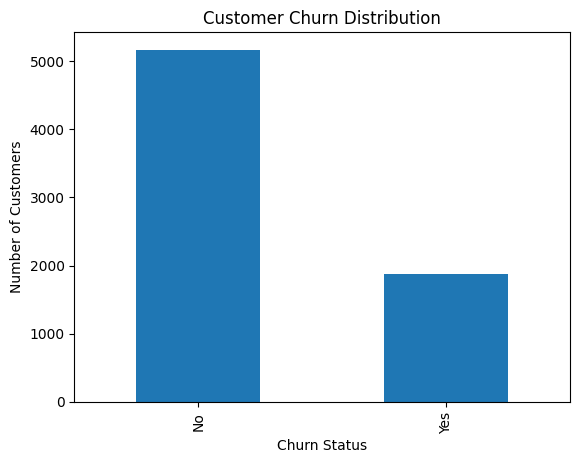

In [4]:
import matplotlib.pyplot as plt

# Churn distribution
churn_counts = df['Churn'].value_counts()

churn_counts.plot(
    kind='bar',
    title='Customer Churn Distribution',
)

plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

Visual Insight: While most customers are retained, the churned segment represents a substantial portion of the customer base, reinforcing the need for targeted retention strategies.

## 2. Tenure & Contract Analysis


In [5]:
# Average tenure by churn status
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

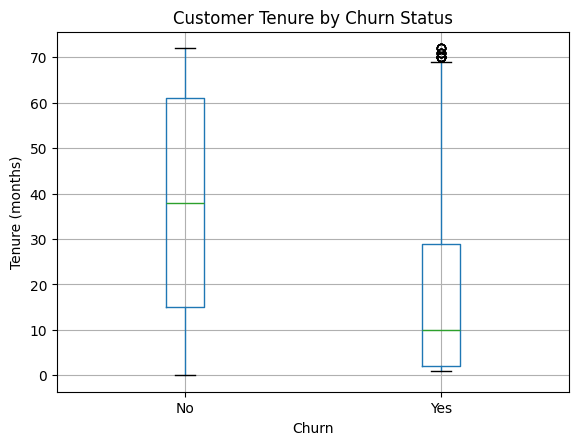

In [6]:
import matplotlib.pyplot as plt

# Tenure distribution by churn status
df.boxplot(column='tenure', by='Churn')

plt.title('Customer Tenure by Churn Status')
plt.suptitle('')  # remove automatic subtitle
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()


Insight: Customers who churn tend to have significantly shorter tenures, indicating that churn risk is highest early in the customer lifecycle.

In [7]:
# Churn rate by contract type
contract_churn = (
    df.groupby('Contract')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

Insight: Month-to-month contracts exhibit substantially higher churn rates compared to one-year and two-year contracts, indicating that longer-term contracts are a strong retention lever.

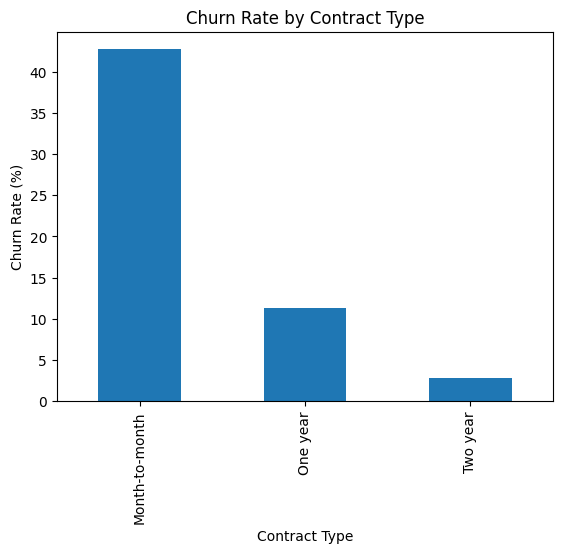

In [8]:
import matplotlib.pyplot as plt

# Plot churn rate by contract type
contract_churn.plot(
    kind='bar',
    title='Churn Rate by Contract Type'
)

plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

Visual Insight: Customers on month-to-month contracts churn at significantly higher rates, reinforcing the importance of contract length as a key retention mechanism.

## 3. Pricing & Payment Sensitivity


In [9]:
# Average monthly charges by churn status
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

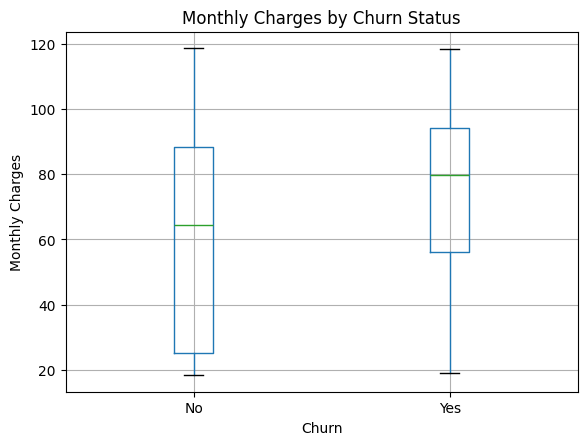

In [10]:
import matplotlib.pyplot as plt

# Monthly charges distribution by churn status
df.boxplot(column='MonthlyCharges', by='Churn')

plt.title('Monthly Charges by Churn Status')
plt.suptitle('')  # remove automatic subtitle
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

Insight: Customers who churn tend to have higher monthly charges, suggesting price sensitivity and potential value perception issues among higher-paying customers.

In [11]:
# Churn rate by payment method
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

Insight: Customers using electronic check payment methods exhibit significantly higher churn, while automatic payment methods are associated with lower churn, suggesting that payment convenience and commitment reduce churn risk.

## 4. Service & Feature Analysis


---

# Churn Modeling (Explainable Baseline)

This section builds an interpretable baseline model to validate whether the EDA insights translate into predictive signal.

The focus is on transparency and business interpretability rather than maximizing raw accuracy.


In [12]:
# Count number of services per customer
service_cols = [
    'PhoneService',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['service_count'] = df[service_cols].apply(
    lambda row: sum(row == 'Yes'), axis=1
)

# Average service count by churn status
df.groupby('Churn')['service_count'].mean()

Churn
No     3.036336
Yes    2.677368
Name: service_count, dtype: float64

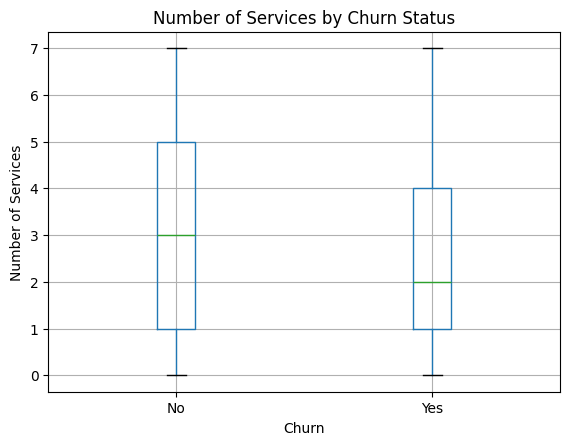

In [13]:
import matplotlib.pyplot as plt

# Service count distribution by churn
df.boxplot(column='service_count', by='Churn')

plt.title('Number of Services by Churn Status')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Number of Services')
plt.show()

Insight: Customers who churn typically have fewer subscribed services, suggesting that deeper service engagement and bundling can significantly reduce churn risk.

## Key EDA Insights (Summary)


### Executive Summary of Findings

1. Churn is material: Approximately ~27% of SME customers churn, representing a significant revenue risk that warrants targeted intervention.

2. Early lifecycle churn dominates: Customers who churn have substantially shorter tenures, indicating that churn risk is highest early in the customer relationship.

3. Contract structure is a key lever: Month-to-month contracts exhibit significantly higher churn rates compared to longer-term contracts, making contract length one of the strongest retention mechanisms.

4. Price and engagement matter: Customers with higher monthly charges and fewer subscribed services are more likely to churn, suggesting that price sensitivity and lack of engagement drive attrition.

# Churn Modeling (Explainable)

## Objective
Build an interpretable churn prediction model to identify high-risk customers and understand the key drivers of churn.

## Modeling Approach
- Binary classification (Churn vs No Churn)
- Logistic Regression for interpretability
- Focus on actionable drivers rather than raw accuracy

### Modeling Approach

Logistic Regression is chosen as a baseline due to its interpretability, stability, and suitability for business decision-making.

This allows stakeholders to understand *why* customers churn, not just *who* will churn.


## Feature Selection

The model focuses on a small set of business-relevant and actionable features identified during EDA:

- tenure: customer relationship duration
- MonthlyCharges: average monthly bill
- Contract: contract length and commitment
- PaymentMethod: billing friction and convenience
- service_count: depth of service engagement

Demographic and identifier variables were excluded to improve interpretability and avoid non-actionable signals.

In [14]:
from sklearn.model_selection import train_test_split

# Create target variable
df['churn_flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Select modeling features
features = [
    'tenure',
    'MonthlyCharges',
    'Contract',
    'PaymentMethod',
    'service_count'
]

X = df[features]
y = df['churn_flag']

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((4930, 8), (2113, 8))

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Initialize model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.63      0.51      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113

ROC AUC: 0.8348482551408567


An ROC AUC of ~0.83 indicates strong separation between churned and retained customers even with a simple baseline model.

### Baseline Model Insight

A simple Logistic Regression model was trained using tenure, pricing, and service features.

The model shows reasonable ability to distinguish churners from non-churners, providing an interpretable baseline for identifying key churn drivers.

This baseline establishes a reference point before considering more complex models.

### Class Imbalance Consideration

Churn is a minority class (~25–30%), which explains the lower recall for churned customers.

This highlights the need for threshold tuning or cost-sensitive learning when deploying churn models for retention actions.


In [ ]:
import pandas as pd

# Extract coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
6,PaymentMethod_Electronic check,0.511556
7,PaymentMethod_Mailed check,0.036989
1,MonthlyCharges,0.036692
5,PaymentMethod_Credit card (automatic),-0.021136
0,tenure,-0.028849
2,service_count,-0.270399
3,Contract_One year,-0.822367
4,Contract_Two year,-1.494536


### Model Interpretation – Key Churn Drivers

The Logistic Regression coefficients provide directional insight into churn drivers:

- Higher monthly charges are associated with increased churn risk, indicating price sensitivity among SME customers.
- Longer tenure reduces churn likelihood, confirming that churn risk is highest early in the customer lifecycle.
- Higher service count is negatively associated with churn, suggesting that bundled services increase customer stickiness.

These results align with exploratory analysis and provide confidence in the model’s interpretability.

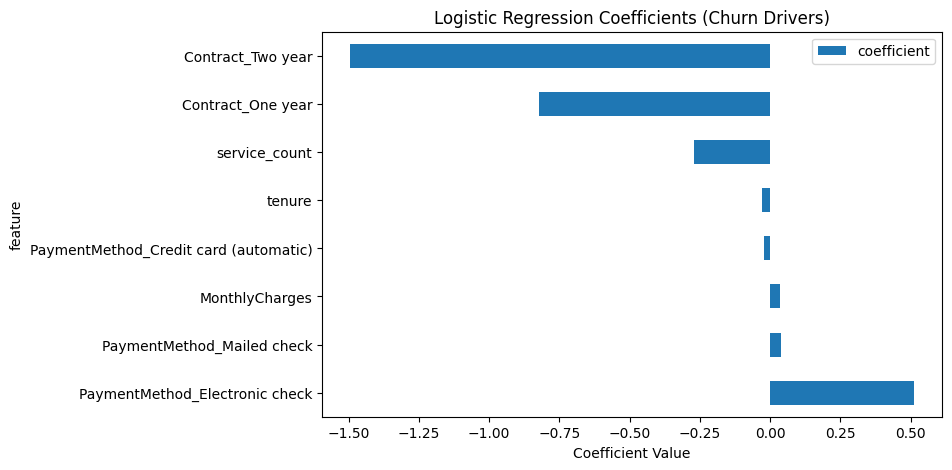

In [17]:
import matplotlib.pyplot as plt

coef_df.set_index("feature").plot(kind="barh", figsize=(8, 5))
plt.title("Logistic Regression Coefficients (Churn Drivers)")
plt.xlabel("Coefficient Value")
plt.show()

## Executive Summary

This analysis examined SME customer churn using exploratory data analysis and an interpretable baseline model.

Key findings:
- Churn is highest early in the customer lifecycle.
- Customers on short contracts and higher monthly charges are more likely to churn.
- Customers with more bundled services exhibit lower churn risk.

The baseline Logistic Regression model provides a transparent foundation for targeted retention strategies, such as early-tenure engagement and pricing interventions.

## Next Steps

- Experiment with tree-based models (Random Forest, XGBoost)
- Tune decision thresholds for retention-focused recall
- Add SHAP for feature-level explanations
- Simulate retention interventions and cost impact
